In [1]:
from cellmender.simulation import simulate_cells
from cellmender.simulation import simple_simulation
import cellmender.utils as cm_utils
from cellmender import denoise_count_matrix
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os

cellmender_dir = os.path.dirname(os.path.abspath(""))
out_dir = os.path.join(cellmender_dir, "notebooks", "output", "debug_sim")

/opt/anaconda3/envs/cellmender/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
%matplotlib widget

In [3]:
data = simulate_cells(G=2000)
print(data)

AnnData object with n_obs × n_vars = 1000 × 2000
    obs: 'cellid', 'celltype', 'is_empty', 'ambient_fraction', 'lib_size'
    var: 'ambient_profile', 'is_marker'
    uns: 'simulation_params', 'marker_sets', 'type_profiles'
    layers: 'noise', 'real'


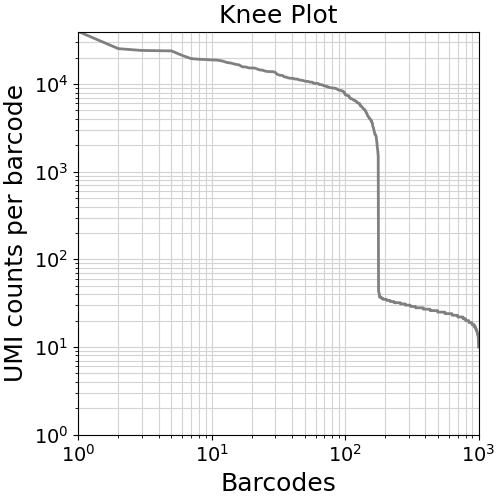

In [4]:
cm_utils.knee_plot(data)

In [ ]:
adata_cellmender_path = os.path.join(out_dir, "adata_cellmender.h5ad")
adata_log_path = os.path.join(out_dir, "cellmender.log")
denoised_data = denoise_count_matrix(data, max_iter=150, beta=0.01, cell_ambient_fraction=0.01, beta_prior_strength=0, verbose=2, adata_out = adata_cellmender_path, log_file = adata_log_path, debug=True)

01:08:04 - INFO - Inferring gene ambient fractions.
01:08:04 - INFO - Added 'ambient_fraction' to adata.var.
01:08:04 - INFO - Inferring celltype profiles.
01:08:04 - INFO - Number of parameters in the cellmender model: 13,240 (alpha_i: 177, beta: 1, gamma_type: 1,062, p_k: 12,000)
01:08:04 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.
01:08:04 - INFO - Performing Sparse EM with 1 Numba thread(s)


Logging to /Users/mcaskey/Desktop/cellmender/notebooks/output/debug_sim/cellmender.log


01:08:06 - INFO - EM Iter   1: ll=-11527281.554 mean_alpha=0.009153 beta=0.009268
01:08:06 - INFO - EM Iter   2: ll=-11523181.841 mean_alpha=0.008793 beta=0.008952
01:08:06 - INFO - EM Iter   3: ll=-11522802.450 mean_alpha=0.008525 beta=0.008715
01:08:06 - INFO - EM Iter   4: ll=-11522601.761 mean_alpha=0.008281 beta=0.008506
01:08:06 - INFO - EM Iter   5: ll=-11522449.290 mean_alpha=0.008063 beta=0.008310
01:08:06 - INFO - EM Iter   6: ll=-11522320.796 mean_alpha=0.007855 beta=0.008124
01:08:06 - INFO - EM Iter   7: ll=-11522207.551 mean_alpha=0.007685 beta=0.007944
01:08:06 - INFO - EM Iter   8: ll=-11522105.009 mean_alpha=0.007519 beta=0.007770
01:08:06 - INFO - EM Iter   9: ll=-11522010.139 mean_alpha=0.007345 beta=0.007601
01:08:06 - INFO - EM Iter  10: ll=-11521920.506 mean_alpha=0.007180 beta=0.007436
01:08:06 - INFO - EM Iter  11: ll=-11521833.819 mean_alpha=0.007024 beta=0.007276
01:08:06 - INFO - EM Iter  12: ll=-11521747.586 mean_alpha=0.006876 beta=0.007119
01:08:06 - INFO 

01:08:07 - INFO - Saving inferred adata to '/Users/mcaskey/Desktop/cellmender/notebooks/output/debug_sim/adata_cellmender.h5ad'


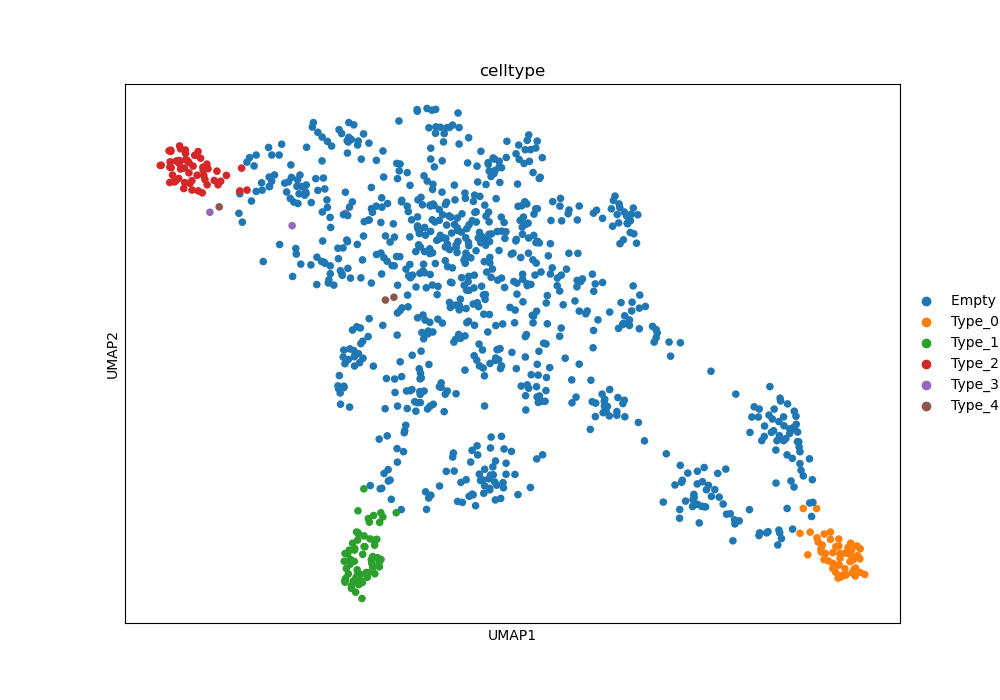

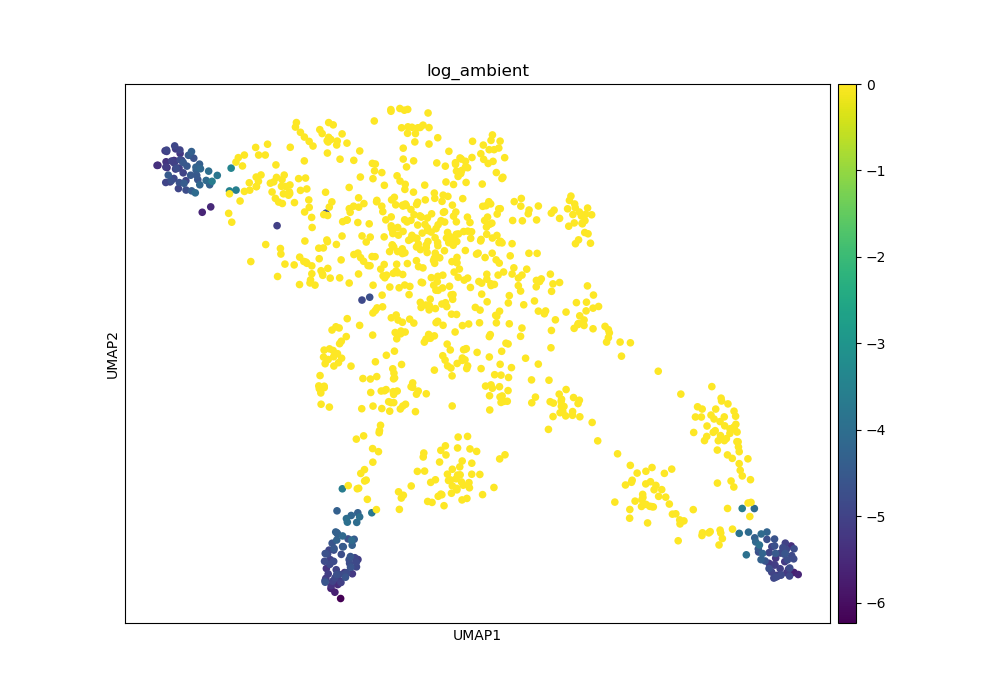

In [6]:
sc.pp.pca(data, n_comps=30)
sc.pp.neighbors(data, n_neighbors=30, n_pcs=30, knn=True)
sc.tl.umap(data)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='celltype', ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
data.obs['log_ambient'] = np.log(data.obs['ambient_fraction'])
sc.pl.umap(data, color='log_ambient', ax=ax)

In [7]:
real_mask = ~denoised_data.obs["is_empty"]
print(denoised_data.obs[real_mask])

          cellid celltype  is_empty  ambient_fraction      lib_size  \
Cell_1         1   Type_0     False          0.011010   7365.412534   
Cell_6         3   Type_2     False          0.014919   6909.402278   
Cell_14        1   Type_0     False          0.006082  15037.749495   
Cell_27        1   Type_0     False          0.007828  11163.441260   
Cell_40        1   Type_0     False          0.020484   3595.373852   
...          ...      ...       ...               ...           ...   
Cell_979       2   Type_1     False          0.001963  41953.688711   
Cell_989       3   Type_2     False          0.011697   7727.134061   
Cell_992       3   Type_2     False          0.008914   9101.610765   
Cell_996       1   Type_0     False          0.020059   5271.483406   
Cell_999       2   Type_1     False          0.006763  10717.958881   

          cell_ambient_fraction  alpha_hat  z_hat  
Cell_1                     0.01   0.007929      1  
Cell_6                     0.01   0.005018 

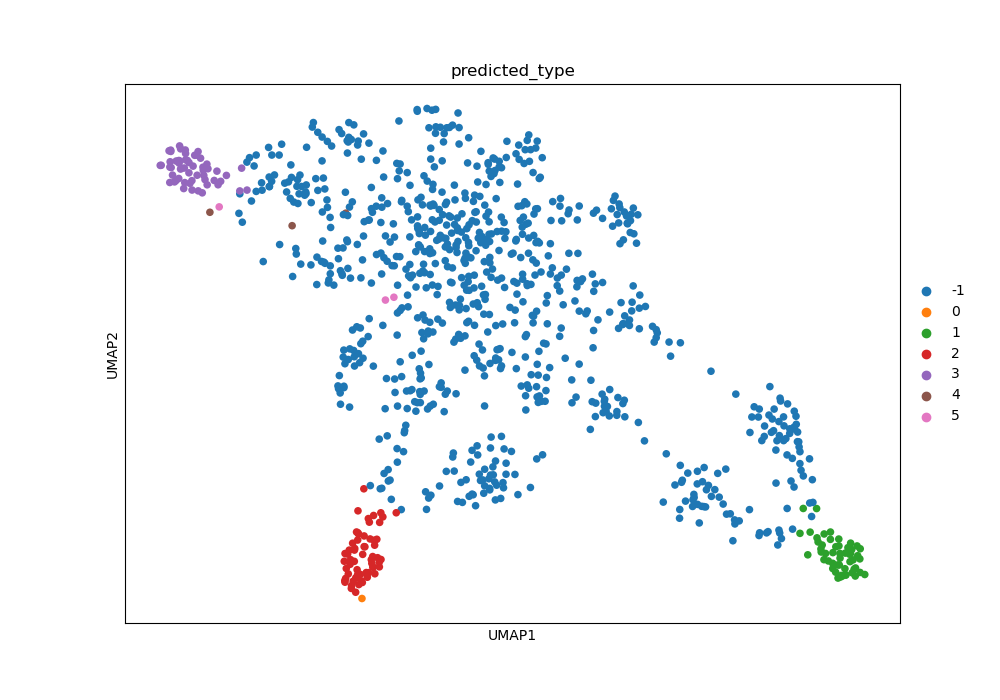

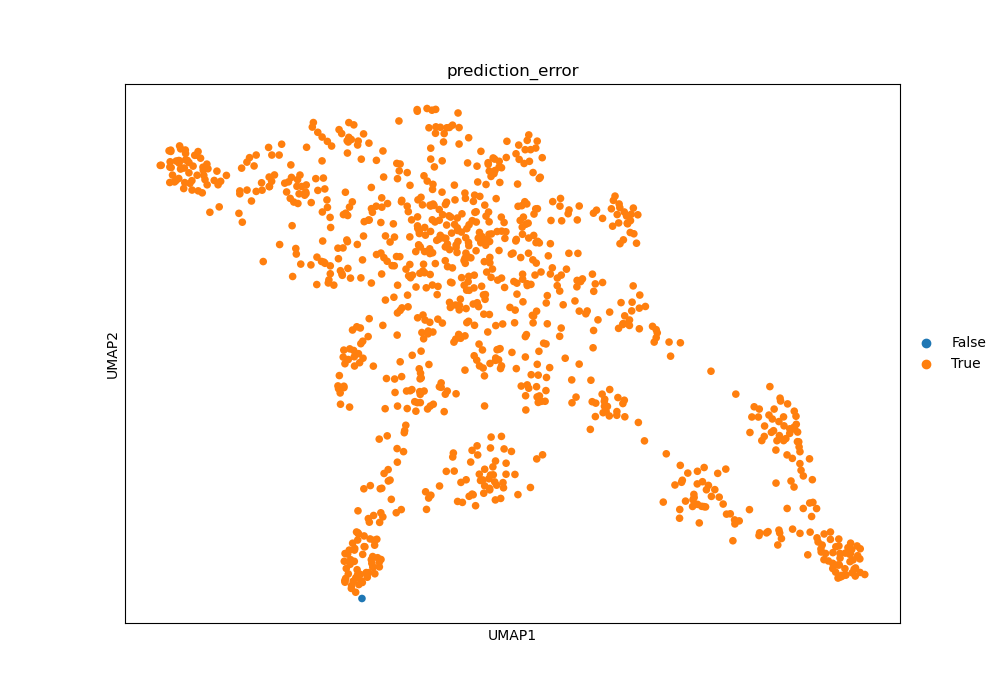

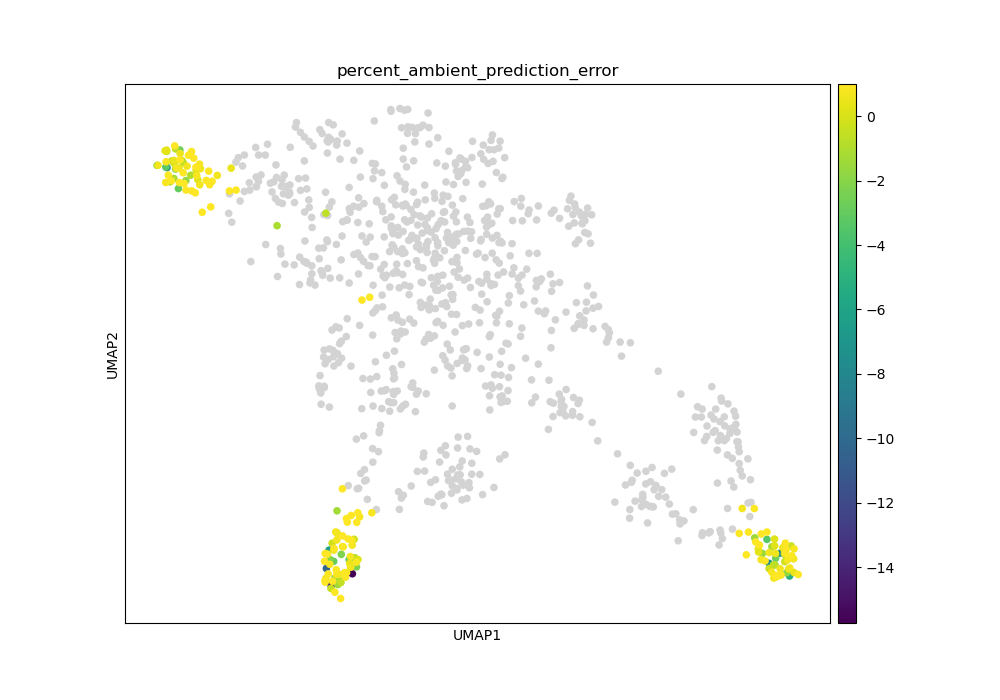

In [8]:
data.obs['percent_ambient_prediction_error'] = (data.obs['ambient_fraction'] - denoised_data.obs['alpha_hat'])/data.obs['ambient_fraction']
data.obs['percent_ambient_prediction_error'] = data.obs['percent_ambient_prediction_error'].mask(~real_mask, np.nan)
data.obs['predicted_type'] = denoised_data.obs['z_hat'].astype('category')
data.obs['prediction_error'] = (denoised_data.obs['z_hat'] == denoised_data.obs['cellid'])

fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='predicted_type', ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='prediction_error',ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='percent_ambient_prediction_error', ax=ax)